## PQK-SVM WIG20 BANKI - wersja 18.09.2026 - 3. Topologia Gwiazdy

In [2]:
%pip install statsmodels

   ---------------------------------------- 0.0/11.3 MB ? eta -:--:--
   ------------------------ --------------- 6.8/11.3 MB 41.7 MB/s eta 0:00:01
   ---------------------------------------- 11.3/11.3 MB 47.1 MB/s  0:00:00

   ---------------------------------------- 0/5 [wrapt]
   -------- ------------------------------- 1/5 [patsy]
   -------- ------------------------------- 1/5 [patsy]
   -------- ------------------------------- 1/5 [patsy]
   -------- ------------------------------- 1/5 [patsy]
   ---------------- ----------------------- 2/5 [interface-meta]
   ------------------------ --------------- 3/5 [formulaic]
   ------------------------ --------------- 3/5 [formulaic]
   ------------------------ --------------- 3/5 [formulaic]
   ------------------------ --------------- 3/5 [formulaic]
   ------------------------ --------------- 3/5 [formulaic]
   ------------------------ --------------- 3/5 [formulaic]
   ------------------------ --------------- 3/5 [formulaic]
   -------

Uszczelnienie przed data leaks

>>> Brak zwalidowanego cache. Generowanie rzutów na Odra QPU...


Progress in queue:   0%|          | 0/1 [08:04<?, ?it/s]



>>> Start rygorystycznej ewaluacji kroczącej (Nested Time-Series CV)...

--- OSTATECZNE WYNIKI BADAWCZE (BEZ DATA LEAKAGE) ---
Baseline (Majority Class) -> Accuracy: 0.5400 | F1: 0.7013


,Accuracy,Balanced Accuracy,F1,AUC,MCC
Classical SVM,0.4867,0.4807,0.5391,0.4954,-0.0390
QPU (1 Layer),0.5044,0.4983,0.5564,0.4848,-0.0035



Przedziały ufności AUC (95% Bootstrap):
QPU: 0.436 - 0.534 (Mediana: 0.484)
SVM: 0.448 - 0.540 (Mediana: 0.495)

Test McNemara (Accuracy QPU vs SVM): p-value = 0.4768


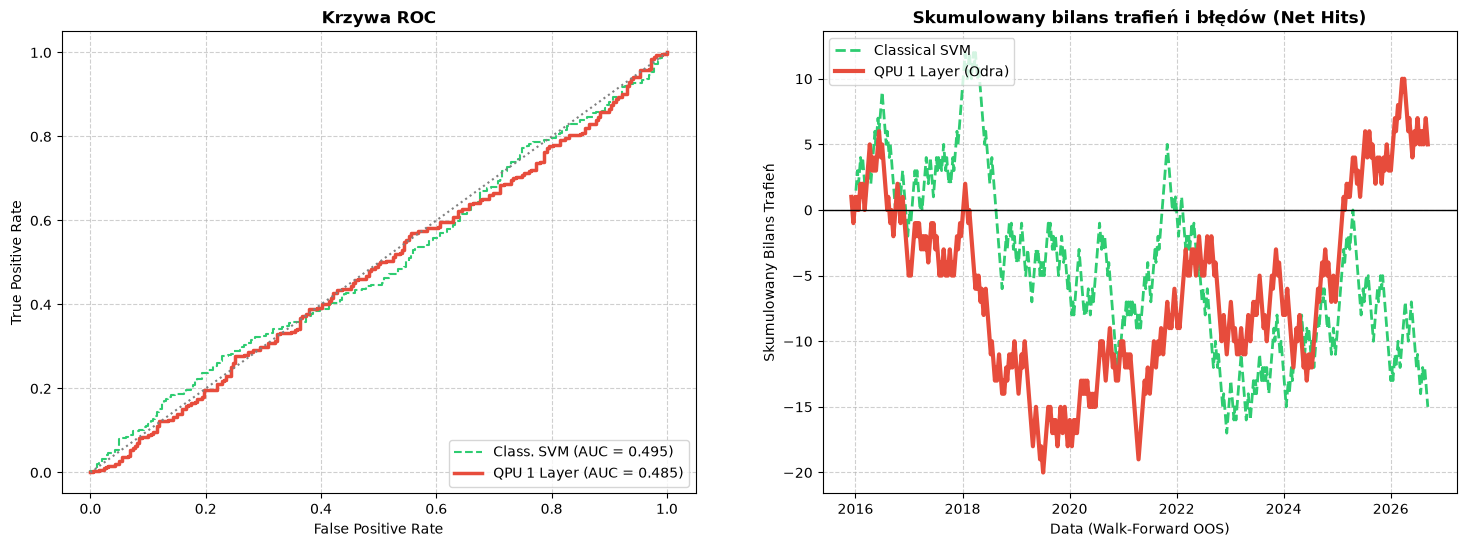

In [2]:
%matplotlib inline

import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dotenv import load_dotenv

from qiskit import QuantumCircuit, transpile
from qiskit.quantum_info import SparsePauliOp
from qiskit.primitives import StatevectorEstimator
from iqm.qiskit_iqm import IQMProvider

from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score, roc_curve,
    balanced_accuracy_score, matthews_corrcoef, confusion_matrix
)
from statsmodels.stats.contingency_tables import mcnemar

import warnings
warnings.filterwarnings("ignore")

# ==========================================
# 1. KONFIGURACJA I WERYFIKACJA DANYCH
# ==========================================
csv_path = "dataset_final.csv" if os.path.exists("dataset_final.csv") else "dane/dataset_final.csv"

FEATURES_MAP = [
    'pbv_pko', 'wibor_3m',         
    'pbv_peo', 'rentownosc_10y',   
    'pbv_san', 'eurpln',           
    'pbv_ing', 'wig20',            
    'pbv_mbk', 'zmiennosc'         
]

df = pd.read_csv(csv_path, index_col=0)
df.index = pd.to_datetime(df.index)
df = df.sort_index()

# Weryfikacja integralności
assert df.index.is_monotonic_increasing, "Błąd: Daty nie są ułożone chronologicznie."
assert df.index.is_unique, "Błąd: Zduplikowane daty w indeksie."
assert df[FEATURES_MAP].notna().all().all(), "Błąd: Brakujące wartości w cechach."
assert df["target_y"].notna().all(), "Błąd: Brakujące wartości w targecie."

X_raw = df[FEATURES_MAP].values
y = df["target_y"].astype(int).values
dates = df.index.values

# ==========================================
# 2. ZEWNĘTRZNE MAPOWANIE KWANTOWE (BEZ DATA LEAKAGE)
# ==========================================
# Granice ustalone przed eksperymentem na bazie wiedzy ekonomicznej
lower_bounds = np.array([0.3, 1.0, 0.3, 1.0, 0.3, 3.5, 0.3, 1500, 0.3, 5.0])
upper_bounds = np.array([3.0, 10.0, 3.0, 10.0, 3.0, 6.0, 3.0, 3000, 3.0, 100.0])

X_quantum = 2 * np.pi * (X_raw - lower_bounds) / (upper_bounds - lower_bounds)
X_quantum = np.clip(X_quantum, 0, 2 * np.pi)

# ==========================================
# 3. GENERATOR OBWODÓW (1 WARSTWA)
# ==========================================
def build_base_ansatz(x, num_qubits=5):
    qc = QuantumCircuit(num_qubits)
    for i in range(num_qubits):
        qc.ry(x[2 * i], i)
        qc.rz(x[2 * i + 1], i)
    # Tylko 1 warstwa splątania
    for i in range(num_qubits - 1):
        qc.cx(i, i + 1)
    qc.cx(num_qubits - 1, 0)
    return qc

def build_measurement_circuits(x, num_qubits=5):
    qc_x = build_base_ansatz(x, num_qubits)
    for i in range(num_qubits): qc_x.h(i)
    qc_x.measure_all()
    
    qc_y = build_base_ansatz(x, num_qubits)
    for i in range(num_qubits): 
        qc_y.sdg(i)
        qc_y.h(i)
    qc_y.measure_all()
    
    qc_z = build_base_ansatz(x, num_qubits)
    qc_z.measure_all()
    return qc_x, qc_y, qc_z

# ==========================================
# 4. BEZPIECZNY CACHE PROJEKCJI
# ==========================================
def expectation_from_counts(counts, num_qubits):
    total_shots = sum(counts.values())
    expvals = np.zeros(num_qubits)
    for bitstring, count in counts.items():
        bits = [1 if b == '0' else -1 for b in reversed(bitstring.replace(" ", ""))]
        for q in range(num_qubits): expvals[q] += bits[q] * count
    return expvals / total_shots

def get_secure_qpu_projections(X_q, dates_arr, features_arr, filepath, num_qubits=5, reps=1, shots=4000, batch_size=50):
    if os.path.exists(filepath):
        print(f">>> Wczytywanie i walidacja cache QPU: {filepath}")
        cache = np.load(filepath, allow_pickle=True)
        if not np.array_equal(cache["dates"], dates_arr):
            raise ValueError("Cache pochodzi z innego zakresu dat.")
        if not np.array_equal(cache["features"], features_arr):
            raise ValueError("Cache pochodzi z innego mapowania cech.")
        if int(cache["reps"]) != reps:
            raise ValueError("Nieprawidłowa głębokość obwodu (reps).")
        if int(cache["shots"]) != shots:
            raise ValueError("Nieprawidłowa liczba strzałów (shots).")
        return cache["phi"]
        
    print(">>> Brak zwalidowanego cache. Generowanie rzutów na Odra QPU...")
    
    # Wczytanie pliku token.env
    env_path = "../token.env" if os.path.exists("../token.env") else "token.env"
    load_dotenv(env_path)
    
    server_url = os.getenv("SERVER")
    if not server_url:
        raise ValueError(f"Błąd: Nie odczytano adresu SERVER z pliku {env_path}.")
        
    provider = IQMProvider(server_url)
    backend = provider.get_backend()
    
    all_circuits = []
    for x in X_q: all_circuits.extend(build_measurement_circuits(x, num_qubits))
    transpiled = transpile(all_circuits, backend=backend, optimization_level=2)
    
    all_counts = []
    for i in range(0, len(transpiled), batch_size):
        batch = transpiled[i : i + batch_size]
        job = backend.run(batch, shots=shots)
        for j in range(len(batch)): all_counts.append(job.result().get_counts(j))
            
    Phi_odra = np.zeros((len(X_q), num_qubits * 3))
    for i in range(len(X_q)):
        for q in range(num_qubits):
            Phi_odra[i, 3 * q + 0] = expectation_from_counts(all_counts[3 * i], num_qubits)[q]
            Phi_odra[i, 3 * q + 1] = expectation_from_counts(all_counts[3 * i + 1], num_qubits)[q]
            Phi_odra[i, 3 * q + 2] = expectation_from_counts(all_counts[3 * i + 2], num_qubits)[q]
            
    np.savez(filepath, phi=Phi_odra, dates=dates_arr, features=np.array(features_arr), reps=reps, shots=shots, num_qubits=num_qubits, backend=backend.name)
    return Phi_odra

cache_filename = "phi_odra_wigbanki_5q_reps1_shots4000_v3.npz"
Phi_real = get_secure_qpu_projections(X_quantum, dates, FEATURES_MAP, cache_filename, reps=1)

# ==========================================
# 5. MODELE I PIPELINE
# ==========================================
def make_svm_pipeline():
    return Pipeline([
        ("scaler", StandardScaler()),
        ("svm", SVC(kernel="rbf", probability=False))
    ])

param_grid = {"svm__C": [0.1, 1.0, 5.0, 10.0], "svm__gamma": ["scale", "auto"]}
inner_cv = TimeSeriesSplit(n_splits=3)

# ==========================================
# 6. EWALUACJA WALK-FORWARD
# ==========================================
TRAIN_WINDOW = 52  
n_samples = len(y)

results = {"y_true": [], "dates": [], "score_rbf": [], "score_qpu": []}

print("\n>>> Start rygorystycznej ewaluacji kroczącej (Nested Time-Series CV)...")

for t in range(TRAIN_WINDOW, n_samples):
    # Klasyczne cechy - surowe
    X_tr_raw = X_raw[t - TRAIN_WINDOW : t]
    X_te_raw = X_raw[t : t + 1]
    
    # Rzuty Kwantowe
    P_tr = Phi_real[t - TRAIN_WINDOW : t]
    P_te = Phi_real[t : t + 1]
    
    y_tr = y[t - TRAIN_WINDOW : t]
    
    results["y_true"].append(y[t])
    results["dates"].append(dates[t])
    
    # Klasyczny SVM na surowych danych
    search_rbf = GridSearchCV(make_svm_pipeline(), param_grid, cv=inner_cv, scoring="roc_auc", n_jobs=-1)
    search_rbf.fit(X_tr_raw, y_tr)
    results["score_rbf"].append(search_rbf.decision_function(X_te_raw)[0])

    # SVM na projekcjach kwantowych (QPU)
    search_qpu = GridSearchCV(make_svm_pipeline(), param_grid, cv=inner_cv, scoring="roc_auc", n_jobs=-1)
    search_qpu.fit(P_tr, y_tr)
    results["score_qpu"].append(search_qpu.decision_function(P_te)[0])

for k in results: results[k] = np.array(results[k])

y_true = results["y_true"]
pred_rbf = (results["score_rbf"] > 0).astype(int)
pred_qpu = (results["score_qpu"] > 0).astype(int)

# ==========================================
# 7. WYLICZENIE METRYK I STATYSTYKI
# ==========================================
# Baseline większościowy
majority_class = int(np.mean(y_true) >= 0.5)
majority_pred = np.full_like(y_true, majority_class)
baseline_acc = accuracy_score(y_true, majority_pred)
baseline_f1 = f1_score(y_true, majority_pred, zero_division=0)

def compute_metrics(y_t, pred, scores):
    return {
        "Accuracy": accuracy_score(y_t, pred),
        "Balanced Accuracy": balanced_accuracy_score(y_t, pred),
        "F1": f1_score(y_t, pred, zero_division=0),
        "AUC": roc_auc_score(y_t, scores),
        "MCC": matthews_corrcoef(y_t, pred)
    }

metrics = {
    "Classical SVM": compute_metrics(y_true, pred_rbf, results["score_rbf"]),
    "QPU (1 Layer)": compute_metrics(y_true, pred_qpu, results["score_qpu"])
}
df_metrics = pd.DataFrame(metrics).T

# Bootstrap AUC
def bootstrap_auc(y_true, scores, n_boot=2000, seed=42):
    rng = np.random.default_rng(seed)
    aucs = []
    for _ in range(n_boot):
        idx = rng.integers(0, len(y_true), len(y_true))
        if len(np.unique(y_true[idx])) < 2: continue
        aucs.append(roc_auc_score(y_true[idx], scores[idx]))
    return np.percentile(aucs, [2.5, 50, 97.5])

qpu_ci = bootstrap_auc(y_true, results["score_qpu"])
rbf_ci = bootstrap_auc(y_true, results["score_rbf"])

# Test McNemara
table = confusion_matrix(pred_rbf == y_true, pred_qpu == y_true)
mcnemar_res = mcnemar(table, exact=False, correction=True)

print("\n--- OSTATECZNE WYNIKI BADAWCZE (BEZ DATA LEAKAGE) ---")
print(f"Baseline (Majority Class) -> Accuracy: {baseline_acc:.4f} | F1: {baseline_f1:.4f}")
display(df_metrics.style.format("{:.4f}"))
print(f"\nPrzedziały ufności AUC (95% Bootstrap):")
print(f"QPU: {qpu_ci[0]:.3f} - {qpu_ci[2]:.3f} (Mediana: {qpu_ci[1]:.3f})")
print(f"SVM: {rbf_ci[0]:.3f} - {rbf_ci[2]:.3f} (Mediana: {rbf_ci[1]:.3f})")
print(f"\nTest McNemara (Accuracy QPU vs SVM): p-value = {mcnemar_res.pvalue:.4f}")

# ==========================================
# 8. WIZUALIZACJE
# ==========================================
fig = plt.figure(figsize=(18, 6))
grid = fig.add_gridspec(1, 2, wspace=0.2)

# [1] Krzywa ROC
ax1 = fig.add_subplot(grid[0, 0])
fpr_rbf, tpr_rbf, _ = roc_curve(y_true, results["score_rbf"])
fpr_qpu, tpr_qpu, _ = roc_curve(y_true, results["score_qpu"])

ax1.plot(fpr_rbf, tpr_rbf, color='#2ecc71', linestyle='--', label=f'Class. SVM (AUC = {metrics["Classical SVM"]["AUC"]:.3f})')
ax1.plot(fpr_qpu, tpr_qpu, color='#e74c3c', linewidth=2.5, label=f'QPU 1 Layer (AUC = {metrics["QPU (1 Layer)"]["AUC"]:.3f})')
ax1.plot([0, 1], [0, 1], color='gray', linestyle=':')
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.set_title('Krzywa ROC', fontweight='bold')
ax1.legend(loc="lower right")
ax1.grid(True, linestyle='--', alpha=0.6)

# [2] Skumulowany bilans trafień i błędów (Net Hits)
ax2 = fig.add_subplot(grid[0, 1])
def get_net_hits(preds): return np.cumsum(np.where(preds == y_true, 1, -1))

ax2.plot(results["dates"], get_net_hits(pred_rbf), color='#2ecc71', linestyle='--', lw=2, label='Classical SVM')
ax2.plot(results["dates"], get_net_hits(pred_qpu), color='#e74c3c', lw=3, label='QPU 1 Layer (Odra)')
ax2.axhline(0, color='black', lw=1)
ax2.set_xlabel("Data (Walk-Forward OOS)")
ax2.set_ylabel("Skumulowany Bilans Trafień")
ax2.set_title("Skumulowany bilans trafień i błędów (Net Hits)", fontweight='bold')
ax2.legend(loc="upper left")
ax2.grid(True, linestyle='--', alpha=0.6)

plt.show()

Dostosowanie pod topologie Odra 5

>>> Causal Scaling zakończony. Bezpiecznych tygodni bez wycieku: 563
>>> Wyliczanie analitycznych rzutów kwantowych lokalnie (StatevectorEstimator)...

>>> Uruchamianie lokalnej walidacji kroczącej (Walk-Forward)...
Zakończono: Pełny Model (Topologia Gwiazdy) | AUC: 0.5243 | F1: 0.6524
Zakończono: Kubit 0 (PKO + WIBOR) | AUC: 0.5162 | F1: 0.6453
Zakończono: Kubit 1 (Pekao + Obligacje - HUB) | AUC: 0.5265 | F1: 0.6483
Zakończono: Kubit 2 (Santander + EURPLN) | AUC: 0.5434 | F1: 0.6619
Zakończono: Kubit 3 (ING + WIG20) | AUC: 0.5075 | F1: 0.6444
Zakończono: Kubit 4 (mBank + Zmiennosc) | AUC: 0.5179 | F1: 0.6464


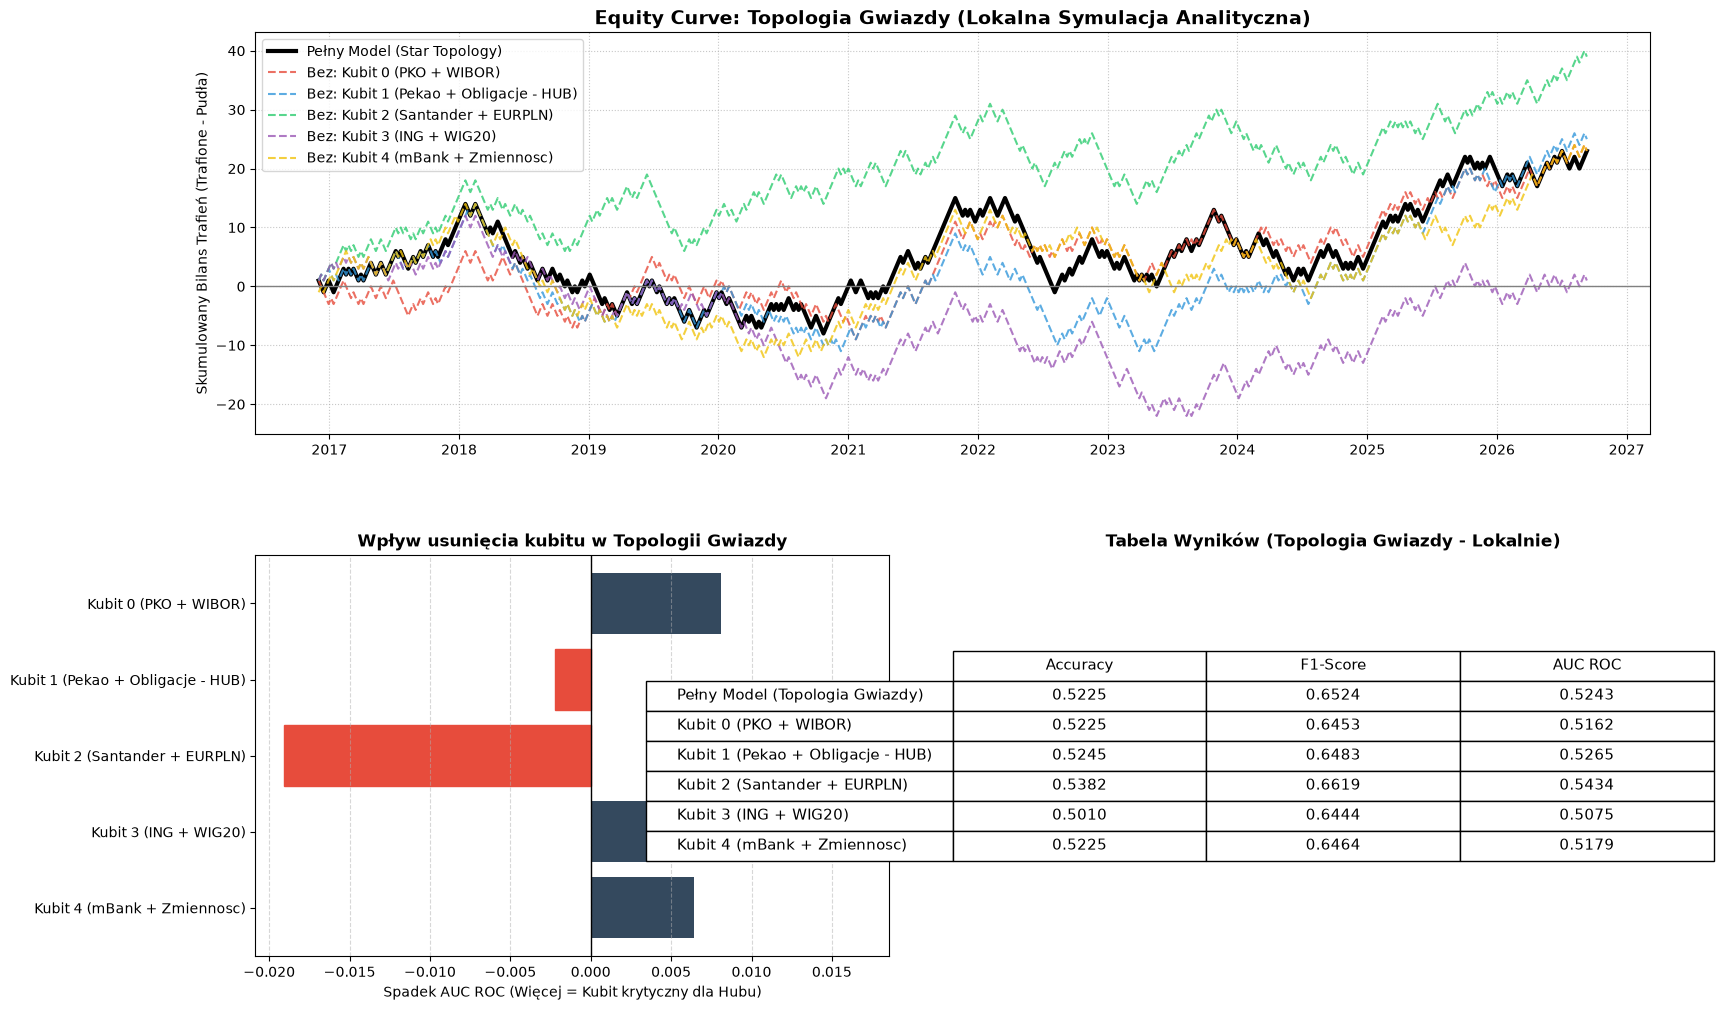

In [3]:
%matplotlib inline

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit
from qiskit.quantum_info import SparsePauliOp
from qiskit.primitives import StatevectorEstimator

from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.metrics.pairwise import rbf_kernel, pairwise_distances

import warnings
warnings.filterwarnings("ignore")

# ==========================================
# 1. KONFIGURACJA I KROCZĄCE SKALOWANIE (0% DATA LEAKAGE)
# ==========================================
csv_path = "dataset_final.csv" if os.path.exists("dataset_final.csv") else "dane/dataset_final.csv"

# Pary przypisane do kubitów
FEATURES_MAP = [
    'pbv_pko', 'wibor_3m',         # Kubit 0
    'pbv_peo', 'rentownosc_10y',   # Kubit 1 (Główny hub z Ablation Study)
    'pbv_san', 'eurpln',           # Kubit 2
    'pbv_ing', 'wig20',            # Kubit 3
    'pbv_mbk', 'zmiennosc'         # Kubit 4
]

df = pd.read_csv(csv_path, index_col=0)
df.index = pd.to_datetime(df.index)
df = df.sort_index()

X_raw = df[FEATURES_MAP].values
y_raw = df["target_y"].values
dates_raw = df.index.values

LOOKBACK = 52
X_norm_list = []
valid_indices = []

# Causal Rolling MinMax - normowanie względem min/max tylko z poprzednich 52 tygodni
for t in range(LOOKBACK, len(X_raw)):
    past_window = X_raw[t - LOOKBACK : t]
    
    min_vals = past_window.min(axis=0)
    max_vals = past_window.max(axis=0)
    range_vals = np.where((max_vals - min_vals) == 0, 1e-8, max_vals - min_vals)
    
    current_scaled = ((X_raw[t] - min_vals) / range_vals) * (2 * np.pi)
    current_scaled = np.clip(current_scaled, 0.0, 2 * np.pi)
    
    X_norm_list.append(current_scaled)
    valid_indices.append(t)

X_norm = np.array(X_norm_list)
y = y_raw[valid_indices]
dates = dates_raw[valid_indices]

print(f">>> Causal Scaling zakończony. Bezpiecznych tygodni bez wycieku: {len(X_norm)}")

# ==========================================
# 2. GENERATOR OBWODÓW (TOPOLOGIA GWIAZDY / STAR TOPOLOGY)
# ==========================================
def build_base_ansatz(x, num_qubits=5):
    qc = QuantumCircuit(num_qubits)
    
    # 1. Warstwa rotacji (Dense Angle Encoding: 10 cech na 5 kubitów)
    for i in range(num_qubits):
        qc.ry(x[2 * i], i)
        qc.rz(x[2 * i + 1], i)
        
    # 2. Topologia Gwiazdy (Star Entanglement z centrami na Kubicie 1)
    # Kubit 1 to Pekao + Obligacje (kluczowy węzeł wykryty w Ablation Study)
    hub_qubit = 1 
    for i in range(num_qubits):
        if i != hub_qubit:
            qc.cx(hub_qubit, i)
            
    return qc

def get_simulator_projections(X_q, num_qubits=5):
    print(">>> Wyliczanie analitycznych rzutów kwantowych lokalnie (StatevectorEstimator)...")
    estimator = StatevectorEstimator()
    observables = []
    
    for q in range(num_qubits):
        for pauli in ['X', 'Y', 'Z']:
            op_str = ['I'] * num_qubits
            op_str[num_qubits - 1 - q] = pauli
            observables.append(SparsePauliOp("".join(op_str)))
            
    Phi = np.zeros((len(X_q), num_qubits * 3))
    for i, x in enumerate(X_q):
        qc = build_base_ansatz(x, num_qubits)
        job = estimator.run([(qc, observables)])
        Phi[i] = job.result()[0].data.evs
        
    return Phi

Phi_full = get_simulator_projections(X_norm)

# ==========================================
# 3. ABLATION STUDY & WALK-FORWARD Z TUNINGIEM PROGU
# ==========================================
TRAIN_WINDOW = 52
n_samples = len(y)

scenarios = {"Pełny Model (Topologia Gwiazdy)": Phi_full}
labels = ["Kubit 0 (PKO + WIBOR)", "Kubit 1 (Pekao + Obligacje - HUB)", 
          "Kubit 2 (Santander + EURPLN)", "Kubit 3 (ING + WIG20)", "Kubit 4 (mBank + Zmiennosc)"]

for q in range(5):
    phi_ablated = Phi_full.copy()
    phi_ablated[:, 3*q : 3*q+3] = 0.0  
    scenarios[labels[q]] = phi_ablated

results_metrics = []
equity_curves = {}

print("\n>>> Uruchamianie lokalnej walidacji kroczącej (Walk-Forward)...")

for name, Phi_data in scenarios.items():
    y_true_out = []
    y_pred_out = []
    p_pred_out = []
    
    for t in range(TRAIN_WINDOW, n_samples):
        P_tr, P_te = Phi_data[t - TRAIN_WINDOW : t], Phi_data[t : t + 1]
        y_tr, y_te = y[t - TRAIN_WINDOW : t], y[t]
        
        y_true_out.append(y_te)
        
        if len(np.unique(y_tr)) > 1:
            # Obliczenie gamma ściśle wewnątrz okna treningowego (brak wycieku)
            dists = pairwise_distances(P_tr)
            gamma_val = 1.0 / (2.0 * (np.median(dists[dists > 0]) ** 2) + 1e-8)
            
            K_tr = rbf_kernel(P_tr, P_tr, gamma=gamma_val)
            K_te = rbf_kernel(P_te, P_tr, gamma=gamma_val)
            
            clf = SVC(kernel="precomputed", probability=True, C=5.0).fit(K_tr, y_tr)
            
            p_tr_pred = clf.predict_proba(K_tr)[:, 1]
            p_te_pred = clf.predict_proba(K_te)[0, 1]
            p_pred_out.append(p_te_pred)
            
            # Dynamic Threshold Tuning na zbiorze treningowym
            best_thresh, best_f1 = 0.5, 0.0
            for thresh in np.linspace(0.35, 0.65, 31):
                f1 = f1_score(y_tr, (p_tr_pred >= thresh).astype(int))
                if f1 > best_f1:
                    best_f1 = f1
                    best_thresh = thresh
            
            y_pred_out.append(1 if p_te_pred >= best_thresh else 0)
        else:
            p_pred_out.append(y_tr[0])
            y_pred_out.append(y_tr[0])

    acc = accuracy_score(y_true_out, y_pred_out)
    f1 = f1_score(y_true_out, y_pred_out)
    auc = roc_auc_score(y_true_out, p_pred_out)
    
    results_metrics.append({"Scenariusz": name, "Accuracy": acc, "F1-Score": f1, "AUC ROC": auc})
    
    hits = np.where(np.array(y_pred_out) == np.array(y_true_out), 1, -1)
    equity_curves[name] = np.cumsum(hits)
    print(f"Zakończono: {name} | AUC: {auc:.4f} | F1: {f1:.4f}")

df_results = pd.DataFrame(results_metrics).set_index("Scenariusz")

# ==========================================
# 4. WIZUALIZACJE DO PUBLIKACJI
# ==========================================
fig = plt.figure(figsize=(18, 12))
grid = fig.add_gridspec(2, 2, hspace=0.3, wspace=0.2)

# [1] Wykres Skumulowanych Trafień
ax1 = fig.add_subplot(grid[0, :])
test_dates = dates[TRAIN_WINDOW:]

ax1.plot(test_dates, equity_curves["Pełny Model (Topologia Gwiazdy)"], color='black', lw=3, label="Pełny Model (Star Topology)")
colors = ['#e74c3c', '#3498db', '#2ecc71', '#9b59b6', '#f1c40f']

for i, q_name in enumerate(labels):
    ax1.plot(test_dates, equity_curves[q_name], color=colors[i], ls='--', lw=1.5, alpha=0.8, label=f"Bez: {q_name}")

ax1.axhline(0, color='gray', lw=1)
ax1.set_title("Equity Curve: Topologia Gwiazdy (Lokalna Symulacja Analityczna)", fontweight='bold', fontsize=14)
ax1.set_ylabel("Skumulowany Bilans Trafień (Trafione - Pudła)")
ax1.legend(loc="upper left")
ax1.grid(True, linestyle=':', alpha=0.7)

# [2] Ważność Cech (Spadek AUC po usunięciu kubitu)
ax2 = fig.add_subplot(grid[1, 0])
base_auc = df_results.loc["Pełny Model (Topologia Gwiazdy)", "AUC ROC"]
auc_drops = []
for q_name in labels:
    drop = base_auc - df_results.loc[q_name, "AUC ROC"]
    auc_drops.append(drop)

bars = ax2.barh(labels, auc_drops, color='#34495e')
for bar in bars:
    if bar.get_width() < 0: bar.set_color('#e74c3c')

ax2.axvline(0, color='black', lw=1)
ax2.set_title("Wpływ usunięcia kubitu w Topologii Gwiazdy", fontweight='bold')
ax2.set_xlabel("Spadek AUC ROC (Więcej = Kubit krytyczny dla Hubu)")
ax2.grid(axis='x', linestyle='--', alpha=0.5)
ax2.invert_yaxis()

# [3] Podsumowanie Metryk
ax3 = fig.add_subplot(grid[1, 1])
ax3.axis('off')
table_data = df_results.copy()
for col in table_data.columns:
    table_data[col] = table_data[col].apply(lambda x: f"{x:.4f}")
    
table = ax3.table(cellText=table_data.values, rowLabels=table_data.index, colLabels=table_data.columns, cellLoc='center', loc='center')
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 1.8)
ax3.set_title("Tabela Wyników (Topologia Gwiazdy - Lokalnie)", fontweight='bold')

plt.show()

>>> Causal Scaling zakończony. Tygodni OOS: 563
>>> Wyliczanie analitycznych rzutów kwantowych (StatevectorEstimator)...
>>> Uruchamianie walidacji kroczącej (Walk-Forward) dla 5 kubitów...

--- WYNIKI SYMULACJI LOKALNEJ (5 KUBITÓW) ---


,Accuracy,Balanced Accuracy,F1,AUC,MCC
Classical SVM (10 features),0.4834,0.4718,0.5570,0.4871,-0.0579
"Quantum Simulator (5 qubits, star)",0.5460,0.5369,0.6041,0.5277,0.0748


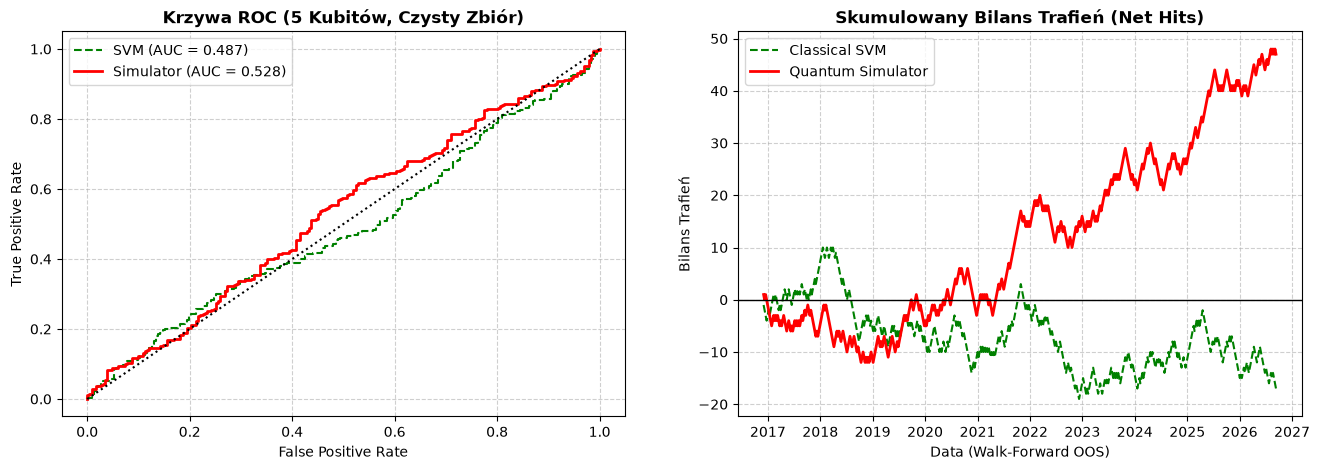

In [ ]:
#Symulator bezszumowy
%matplotlib inline

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit
from qiskit.quantum_info import SparsePauliOp
from qiskit.primitives import StatevectorEstimator

from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score, roc_curve,
    balanced_accuracy_score, matthews_corrcoef
)

import warnings
warnings.filterwarnings("ignore")

# ==========================================
# 1. KONFIGURACJA I PRZYCZYNOWE SKALOWANIE (0% DATA LEAKAGE)
# ==========================================
csv_path = "dataset_final.csv" if os.path.exists("dataset_final.csv") else "dane/dataset_final.csv"

# Przywrócenie pełnych 5 kubitów (10 cech)
FEATURES_MAP = [
    'pbv_pko', 'wibor_3m',         # Kubit 0
    'pbv_peo', 'rentownosc_10y',   # Kubit 1 (HUB)
    'pbv_san', 'eurpln',           # Kubit 2
    'pbv_ing', 'wig20',            # Kubit 3
    'pbv_mbk', 'zmiennosc'         # Kubit 4
]

df = pd.read_csv(csv_path, index_col=0)
df.index = pd.to_datetime(df.index)
df = df.sort_index()

X_raw = df[FEATURES_MAP].values
y_raw = df["target_y"].astype(int).values
dates_raw = df.index.values

LOOKBACK = 52
X_norm_list, valid_indices = [], []

for t in range(LOOKBACK, len(X_raw)):
    past_window = X_raw[t - LOOKBACK : t]
    min_vals = past_window.min(axis=0)
    max_vals = past_window.max(axis=0)
    range_vals = np.where((max_vals - min_vals) == 0, 1e-8, max_vals - min_vals)
    
    current_scaled = ((X_raw[t] - min_vals) / range_vals) * (2 * np.pi)
    current_scaled = np.clip(current_scaled, 0.0, 2 * np.pi)
    
    X_norm_list.append(current_scaled)
    valid_indices.append(t)

X_quantum = np.array(X_norm_list)
y = y_raw[valid_indices]
dates = dates_raw[valid_indices]
X_raw_valid = X_raw[valid_indices]

print(f">>> Causal Scaling zakończony. Tygodni OOS: {len(X_quantum)}")

# ==========================================
# 2. GENERATOR OBWODÓW (TOPOLOGIA GWIAZDY - 5 KUBITÓW)
# ==========================================
NUM_QUBITS = 5
HUB_QUBIT = 1

def build_base_ansatz(x, num_qubits=NUM_QUBITS, hub_qubit=HUB_QUBIT):
    qc = QuantumCircuit(num_qubits)
    for i in range(num_qubits):
        qc.ry(x[2 * i], i)
        qc.rz(x[2 * i + 1], i)
    for i in range(num_qubits):
        if i != hub_qubit:
            qc.cx(hub_qubit, i)
    return qc

def get_simulator_projections(X_q, num_qubits=NUM_QUBITS):
    print(">>> Wyliczanie analitycznych rzutów kwantowych (StatevectorEstimator)...")
    estimator = StatevectorEstimator()
    observables = []
    
    for q in range(num_qubits):
        for pauli in ['X', 'Y', 'Z']:
            op_str = ['I'] * num_qubits
            op_str[num_qubits - 1 - q] = pauli
            observables.append(SparsePauliOp("".join(op_str)))
            
    Phi = np.zeros((len(X_q), num_qubits * 3))
    for i, x in enumerate(X_q):
        qc = build_base_ansatz(x, num_qubits)
        job = estimator.run([(qc, observables)])
        Phi[i] = job.result()[0].data.evs
        
    return Phi

Phi_sim = get_simulator_projections(X_quantum)

# ==========================================
# 3. WALIDACJA WALK-FORWARD
# ==========================================
def make_svm_pipeline():
    return Pipeline([("scaler", StandardScaler()), ("svm", SVC(kernel="rbf", probability=False))])

param_grid = {"svm__C": [0.1, 1.0, 5.0, 10.0], "svm__gamma": ["scale", "auto"]}
inner_cv = TimeSeriesSplit(n_splits=3)
TRAIN_WINDOW = 52
n_samples = len(y)

results = {"y_true": [], "dates": [], "score_rbf": [], "score_sim": []}

print(">>> Uruchamianie walidacji kroczącej (Walk-Forward) dla 5 kubitów...")

for t in range(TRAIN_WINDOW, n_samples):
    X_tr_raw, X_te_raw = X_raw_valid[t - TRAIN_WINDOW : t], X_raw_valid[t : t + 1]
    P_tr, P_te = Phi_sim[t - TRAIN_WINDOW : t], Phi_sim[t : t + 1]
    y_tr = y[t - TRAIN_WINDOW : t]
    
    results["y_true"].append(y[t])
    results["dates"].append(dates[t])
    
    search_rbf = GridSearchCV(make_svm_pipeline(), param_grid, cv=inner_cv, scoring="roc_auc", n_jobs=1).fit(X_tr_raw, y_tr)
    results["score_rbf"].append(search_rbf.decision_function(X_te_raw)[0])

    search_sim = GridSearchCV(make_svm_pipeline(), param_grid, cv=inner_cv, scoring="roc_auc", n_jobs=1).fit(P_tr, y_tr)
    results["score_sim"].append(search_sim.decision_function(P_te)[0])

for k in results: results[k] = np.array(results[k])

y_true = results["y_true"]
pred_rbf = (results["score_rbf"] > 0).astype(int)
pred_sim = (results["score_sim"] > 0).astype(int)

# ==========================================
# 4. METRYKI I WIZUALIZACJA
# ==========================================
def compute_metrics(y_t, pred, scores):
    return {
        "Accuracy": accuracy_score(y_t, pred),
        "Balanced Accuracy": balanced_accuracy_score(y_t, pred),
        "F1": f1_score(y_t, pred, zero_division=0),
        "AUC": roc_auc_score(y_t, scores),
        "MCC": matthews_corrcoef(y_t, pred)
    }

df_metrics = pd.DataFrame({
    "Classical SVM (10 features)": compute_metrics(y_true, pred_rbf, results["score_rbf"]),
    "Quantum Simulator (5 qubits, star)": compute_metrics(y_true, pred_sim, results["score_sim"])
}).T

print("\n--- WYNIKI SYMULACJI LOKALNEJ (5 KUBITÓW) ---")
display(df_metrics.style.format("{:.4f}"))

fig, ax = plt.subplots(1, 2, figsize=(16, 5))
fpr_rbf, tpr_rbf, _ = roc_curve(y_true, results["score_rbf"])
fpr_sim, tpr_sim, _ = roc_curve(y_true, results["score_sim"])

ax[0].plot(fpr_rbf, tpr_rbf, 'g--', label=f'SVM (AUC = {df_metrics.loc["Classical SVM (10 features)", "AUC"]:.3f})')
ax[0].plot(fpr_sim, tpr_sim, 'r-', lw=2, label=f'Simulator (AUC = {df_metrics.loc["Quantum Simulator (5 qubits, star)", "AUC"]:.3f})')
ax[0].plot([0, 1], [0, 1], 'k:')
ax[0].set_title('Krzywa ROC (5 Kubitów, Czysty Zbiór)', fontweight='bold')
ax[0].set_xlabel('False Positive Rate')
ax[0].set_ylabel('True Positive Rate')
ax[0].legend()
ax[0].grid(True, linestyle='--', alpha=0.6)

ax[1].plot(results["dates"], np.cumsum(np.where(pred_rbf == y_true, 1, -1)), 'g--', label='Classical SVM')
ax[1].plot(results["dates"], np.cumsum(np.where(pred_sim == y_true, 1, -1)), 'r-', lw=2, label='Quantum Simulator')
ax[1].axhline(0, color='black', lw=1)
ax[1].set_title('Skumulowany Bilans Trafień (Net Hits)', fontweight='bold')
ax[1].set_xlabel('Data (Walk-Forward OOS)')
ax[1].set_ylabel('Bilans Trafień')
ax[1].legend()
ax[1].grid(True, linestyle='--', alpha=0.6)

plt.show()

>>> Causal Scaling zakończony. Tygodni OOS bez wycieku: 563
>>> Brak zwalidowanego cache. Wysyłanie zadań do Odra QPU...
  Zalogowano do: IQMBackend
  Transpilacja obwodów dla topologii IQMBackend...
  Wysyłanie paczki 1 / 34...
  Wysyłanie paczki 2 / 34...
  Wysyłanie paczki 3 / 34...
  Wysyłanie paczki 4 / 34...
  Wysyłanie paczki 5 / 34...
  Wysyłanie paczki 6 / 34...
  Wysyłanie paczki 7 / 34...
  Wysyłanie paczki 8 / 34...
  Wysyłanie paczki 9 / 34...
  Wysyłanie paczki 10 / 34...
  Wysyłanie paczki 11 / 34...
  Wysyłanie paczki 12 / 34...
  Wysyłanie paczki 13 / 34...
  Wysyłanie paczki 14 / 34...
  Wysyłanie paczki 15 / 34...
  Wysyłanie paczki 16 / 34...
  Wysyłanie paczki 17 / 34...
  Wysyłanie paczki 18 / 34...
  Wysyłanie paczki 19 / 34...
  Wysyłanie paczki 20 / 34...
  Wysyłanie paczki 21 / 34...
  Wysyłanie paczki 22 / 34...
  Wysyłanie paczki 23 / 34...
  Wysyłanie paczki 24 / 34...
  Wysyłanie paczki 25 / 34...
  Wysyłanie paczki 26 / 34...
  Wysyłanie paczki 27 / 34...

Progress in queue:   0%|          | 0/1 [01:22<?, ?it/s]


  Wysyłanie paczki 31 / 34...
  Wysyłanie paczki 32 / 34...
  Wysyłanie paczki 33 / 34...
  Wysyłanie paczki 34 / 34...

>>> Uruchamianie walidacji kroczącej (Walk-Forward)...

--- OSTATECZNE WYNIKI EKSPERYMENTU NA SPRZĘCIE FIZYCZNYM ---


,Accuracy,Balanced Accuracy,F1,AUC,MCC
Classical SVM,0.4834,0.4718,0.5570,0.4871,-0.0579
Odra QPU (Star),0.5342,0.5235,0.5993,0.5242,0.0480



Test McNemara p-value: 0.0453
Wniosek: Różnica między modelem QPU a klasycznym jest ISTOTNA STATYSTYCZNIE (p < 0.05)!


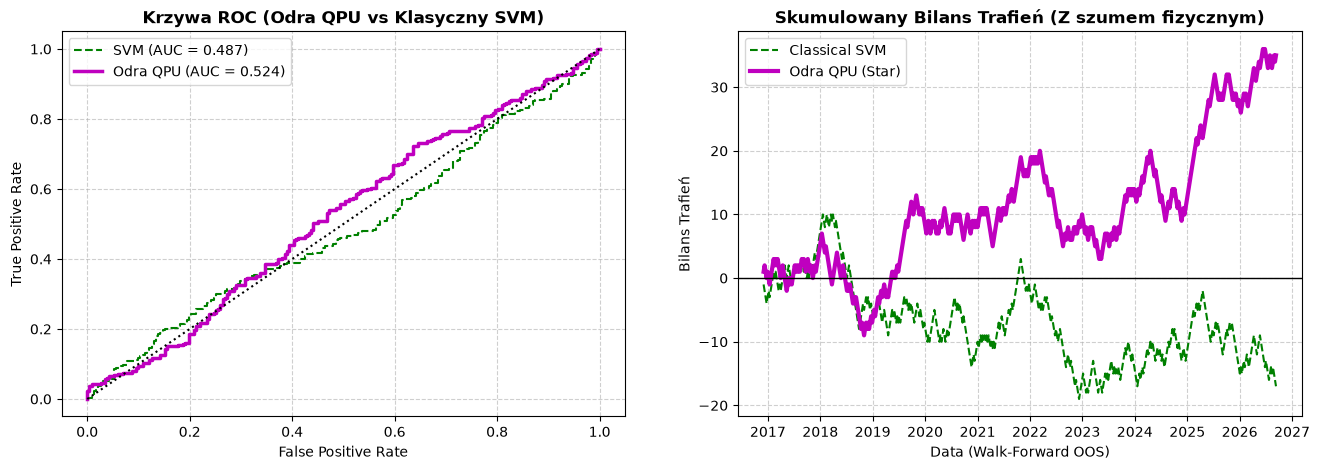

In [2]:
#odra
%matplotlib inline

import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dotenv import load_dotenv

from qiskit import QuantumCircuit, transpile
try:
    from iqm.qiskit import IQMProvider
except ImportError:
    from iqm.qiskit_iqm import IQMProvider

from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score, roc_curve,
    balanced_accuracy_score, matthews_corrcoef, confusion_matrix
)
from statsmodels.stats.contingency_tables import mcnemar

import warnings
warnings.filterwarnings("ignore")

# ==========================================
# 1. KONFIGURACJA I PRZYCZYNOWE SKALOWANIE (0% DATA LEAKAGE)
# ==========================================
csv_path = "dataset_final.csv" if os.path.exists("dataset_final.csv") else "dane/dataset_final.csv"

FEATURES_MAP = [
    'pbv_pko', 'wibor_3m',         # Kubit 0
    'pbv_peo', 'rentownosc_10y',   # Kubit 1 (HUB)
    'pbv_san', 'eurpln',           # Kubit 2
    'pbv_ing', 'wig20',            # Kubit 3
    'pbv_mbk', 'zmiennosc'         # Kubit 4
]

df = pd.read_csv(csv_path, index_col=0)
df.index = pd.to_datetime(df.index)
df = df.sort_index()

X_raw = df[FEATURES_MAP].values
y_raw = df["target_y"].astype(int).values
dates_raw = df.index.values

LOOKBACK = 52
X_norm_list, valid_indices = [], []

for t in range(LOOKBACK, len(X_raw)):
    past_window = X_raw[t - LOOKBACK : t]
    min_vals = past_window.min(axis=0)
    max_vals = past_window.max(axis=0)
    range_vals = np.where((max_vals - min_vals) == 0, 1e-8, max_vals - min_vals)
    
    current_scaled = ((X_raw[t] - min_vals) / range_vals) * (2 * np.pi)
    current_scaled = np.clip(current_scaled, 0.0, 2 * np.pi)
    
    X_norm_list.append(current_scaled)
    valid_indices.append(t)

X_quantum = np.array(X_norm_list)
y = y_raw[valid_indices]
dates = dates_raw[valid_indices]
X_raw_valid = X_raw[valid_indices]

print(f">>> Causal Scaling zakończony. Tygodni OOS bez wycieku: {len(X_quantum)}")

# ==========================================
# 2. GENERATOR OBWODÓW I METRYKI QPU
# ==========================================
HUB_QUBIT = 1

def build_base_ansatz(x, num_qubits=5, hub_qubit=HUB_QUBIT):
    qc = QuantumCircuit(num_qubits)
    for i in range(num_qubits):
        qc.ry(x[2 * i], i)
        qc.rz(x[2 * i + 1], i)
    for i in range(num_qubits):
        if i != hub_qubit:
            qc.cx(hub_qubit, i)
    return qc

def build_measurement_circuits(x, num_qubits=5, hub_qubit=HUB_QUBIT):
    qc_x = build_base_ansatz(x, num_qubits, hub_qubit)
    for i in range(num_qubits): qc_x.h(i)
    qc_x.measure_all()
    
    qc_y = build_base_ansatz(x, num_qubits, hub_qubit)
    for i in range(num_qubits): 
        qc_y.sdg(i)
        qc_y.h(i)
    qc_y.measure_all()
    
    qc_z = build_base_ansatz(x, num_qubits, hub_qubit)
    qc_z.measure_all()
    return qc_x, qc_y, qc_z

def expectation_from_counts(counts, num_qubits):
    total_shots = sum(counts.values())
    expvals = np.zeros(num_qubits)
    for bitstring, count in counts.items():
        bits = [1 if b == '0' else -1 for b in reversed(bitstring.replace(" ", ""))]
        for q in range(num_qubits): expvals[q] += bits[q] * count
    return expvals / total_shots

def get_secure_qpu_projections(X_q, dates_arr, features_arr, filepath, num_qubits=5, reps=1, shots=4000, batch_size=50):
    if os.path.exists(filepath):
        print(f">>> Wczytywanie zwalidowanego cache QPU: {filepath}")
        cache = np.load(filepath, allow_pickle=True)
        if not np.array_equal(cache["dates"], dates_arr): raise ValueError("Mismatch dat w cache.")
        return cache["phi"]
        
    print(">>> Brak zwalidowanego cache. Wysyłanie zadań do Odra QPU...")
    
    # Bezpieczne ładowanie pliku z tokenem
    env_paths = ["../iqm_token.env", "iqm_token.env", "token.env", "../token.env"]
    for path in env_paths:
        if os.path.exists(path):
            load_dotenv(path)
            break
            
    server_url = os.getenv("SERVER")
    if not server_url: 
        raise ValueError("Błąd: Brak adresu SERVER w zmiennych środowiskowych. Upewnij się, że plik z tokenem istnieje.")
        
    provider = IQMProvider(server_url)
    backend = provider.get_backend()
    print(f"  Zalogowano do: {backend.name}")
    
    all_circuits = []
    for x in X_q: all_circuits.extend(build_measurement_circuits(x, num_qubits, HUB_QUBIT))
    
    print(f"  Transpilacja obwodów dla topologii {backend.name}...")
    transpiled = transpile(all_circuits, backend=backend, optimization_level=2)
    
    all_counts = []
    for i in range(0, len(transpiled), batch_size):
        batch = transpiled[i : i + batch_size]
        print(f"  Wysyłanie paczki {i//batch_size + 1} / {(len(transpiled)-1)//batch_size + 1}...")
        job = backend.run(batch, shots=shots)
        for j in range(len(batch)): all_counts.append(job.result().get_counts(j))
            
    Phi_odra = np.zeros((len(X_q), num_qubits * 3))
    for i in range(len(X_q)):
        for q in range(num_qubits):
            Phi_odra[i, 3 * q + 0] = expectation_from_counts(all_counts[3 * i], num_qubits)[q]
            Phi_odra[i, 3 * q + 1] = expectation_from_counts(all_counts[3 * i + 1], num_qubits)[q]
            Phi_odra[i, 3 * q + 2] = expectation_from_counts(all_counts[3 * i + 2], num_qubits)[q]
            
    np.savez(filepath, phi=Phi_odra, dates=dates_arr, features=np.array(features_arr), reps=reps, shots=shots, num_qubits=num_qubits, backend=backend.name)
    return Phi_odra

cache_filename = "phi_odra_wigbanki_5q_star_reps1_shots4000_v1.npz"
Phi_real = get_secure_qpu_projections(X_quantum, dates, FEATURES_MAP, cache_filename, reps=1)

# ==========================================
# 3. EWALUACJA WALK-FORWARD I STATYSTYKA
# ==========================================
def make_svm_pipeline():
    return Pipeline([("scaler", StandardScaler()), ("svm", SVC(kernel="rbf", probability=False))])

param_grid = {"svm__C": [0.1, 1.0, 5.0, 10.0], "svm__gamma": ["scale", "auto"]}
inner_cv = TimeSeriesSplit(n_splits=3)
TRAIN_WINDOW = 52
n_samples = len(y)

results = {"y_true": [], "dates": [], "score_rbf": [], "score_qpu": []}

print("\n>>> Uruchamianie walidacji kroczącej (Walk-Forward)...")

for t in range(TRAIN_WINDOW, n_samples):
    X_tr_raw, X_te_raw = X_raw_valid[t - TRAIN_WINDOW : t], X_raw_valid[t : t + 1]
    P_tr, P_te = Phi_real[t - TRAIN_WINDOW : t], Phi_real[t : t + 1]
    y_tr = y[t - TRAIN_WINDOW : t]
    
    results["y_true"].append(y[t])
    results["dates"].append(dates[t])
    
    # n_jobs=1 dla bezpieczeństwa pętli na Windowsie
    search_rbf = GridSearchCV(make_svm_pipeline(), param_grid, cv=inner_cv, scoring="roc_auc", n_jobs=1).fit(X_tr_raw, y_tr)
    results["score_rbf"].append(search_rbf.decision_function(X_te_raw)[0])

    search_qpu = GridSearchCV(make_svm_pipeline(), param_grid, cv=inner_cv, scoring="roc_auc", n_jobs=1).fit(P_tr, y_tr)
    results["score_qpu"].append(search_qpu.decision_function(P_te)[0])

for k in results: results[k] = np.array(results[k])

y_true = results["y_true"]
pred_rbf = (results["score_rbf"] > 0).astype(int)
pred_qpu = (results["score_qpu"] > 0).astype(int)

def compute_metrics(y_t, pred, scores):
    return {
        "Accuracy": accuracy_score(y_t, pred),
        "Balanced Accuracy": balanced_accuracy_score(y_t, pred),
        "F1": f1_score(y_t, pred, zero_division=0),
        "AUC": roc_auc_score(y_t, scores),
        "MCC": matthews_corrcoef(y_t, pred)
    }

df_metrics = pd.DataFrame({
    "Classical SVM": compute_metrics(y_true, pred_rbf, results["score_rbf"]),
    "Odra QPU (Star)": compute_metrics(y_true, pred_qpu, results["score_qpu"])
}).T

print("\n--- OSTATECZNE WYNIKI EKSPERYMENTU NA SPRZĘCIE FIZYCZNYM ---")
display(df_metrics.style.format("{:.4f}"))

# Test McNemara
table = confusion_matrix(pred_rbf == y_true, pred_qpu == y_true)
mcnemar_res = mcnemar(table, exact=False, correction=True)
print(f"\nTest McNemara p-value: {mcnemar_res.pvalue:.4f}")
if mcnemar_res.pvalue < 0.05:
    print("Wniosek: Różnica między modelem QPU a klasycznym jest ISTOTNA STATYSTYCZNIE (p < 0.05)!")
else:
    print("Wniosek: Różnica między modelem QPU a klasycznym nie wykazuje silnej istotności statystycznej (p >= 0.05).")

# Wykresy
fig, ax = plt.subplots(1, 2, figsize=(16, 5))
fpr_rbf, tpr_rbf, _ = roc_curve(y_true, results["score_rbf"])
fpr_qpu, tpr_qpu, _ = roc_curve(y_true, results["score_qpu"])

ax[0].plot(fpr_rbf, tpr_rbf, 'g--', label=f'SVM (AUC = {df_metrics.loc["Classical SVM", "AUC"]:.3f})')
ax[0].plot(fpr_qpu, tpr_qpu, 'm-', lw=2.5, label=f'Odra QPU (AUC = {df_metrics.loc["Odra QPU (Star)", "AUC"]:.3f})')
ax[0].plot([0, 1], [0, 1], 'k:')
ax[0].set_title('Krzywa ROC (Odra QPU vs Klasyczny SVM)', fontweight='bold')
ax[0].set_xlabel('False Positive Rate')
ax[0].set_ylabel('True Positive Rate')
ax[0].legend()
ax[0].grid(True, linestyle='--', alpha=0.6)

ax[1].plot(results["dates"], np.cumsum(np.where(pred_rbf == y_true, 1, -1)), 'g--', label='Classical SVM')
ax[1].plot(results["dates"], np.cumsum(np.where(pred_qpu == y_true, 1, -1)), 'm-', lw=3, label='Odra QPU (Star)')
ax[1].axhline(0, color='black', lw=1)
ax[1].set_title('Skumulowany Bilans Trafień (Z szumem fizycznym)', fontweight='bold')
ax[1].set_xlabel('Data (Walk-Forward OOS)')
ax[1].set_ylabel('Bilans Trafień')
ax[1].legend()
ax[1].grid(True, linestyle='--', alpha=0.6)

plt.show()